In [149]:
# 1. Import libraries, set definitions, and define file paths

# Core Python libraries
import os
import json
import getpass
import warnings
from collections import defaultdict

# Data analysis libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Similarity analysis for EDA
from sklearn.metrics.pairwise import cosine_similarity

# Surprise recommendation-system libraries
from surprise import Dataset, Reader, KNNBasic, BaselineOnly, SVD, accuracy
from surprise.model_selection import train_test_split

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 6604

# Pandas display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Input file paths
BOOKS_FILE = "Books.csv"
RATINGS_FILE = "Ratings.csv"

# Output folder for saved app artifacts
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Libraries imported successfully.")
print(f"Books file path: {BOOKS_FILE}")
print(f"Ratings file path: {RATINGS_FILE}")
print(f"Artifact folder: {ARTIFACT_DIR}")

Libraries imported successfully.
Books file path: Books.csv
Ratings file path: Ratings.csv
Artifact folder: artifacts


In [150]:
###############################################################
# 2. LOAD DATA AND PERFORM INITIAL INSPECTION
###############################################################

# Check current working folder
print("Current working directory:")
print(os.getcwd())

# Flexible file path setup
# This allows the notebook to work whether it is inside Project2 Folder
# or one folder above Project2 Folder.

if os.path.exists("Books.csv") and os.path.exists("Ratings.csv"):
    BOOKS_FILE = "Books.csv"
    RATINGS_FILE = "Ratings.csv"

elif os.path.exists(os.path.join("Project2 Folder", "Books.csv")) and os.path.exists(os.path.join("Project2 Folder", "Ratings.csv")):
    BOOKS_FILE = os.path.join("Project2 Folder", "Books.csv")
    RATINGS_FILE = os.path.join("Project2 Folder", "Ratings.csv")

else:
    raise FileNotFoundError(
        "Could not find Books.csv and Ratings.csv. "
        "Make sure they are either in the same folder as this notebook "
        "or inside a folder named 'Project2 Folder'."
    )

print(f"\nBooks file path: {BOOKS_FILE}")
print(f"Ratings file path: {RATINGS_FILE}")

# Load Goodreads book metadata and user rating data
books = pd.read_csv(BOOKS_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print("\nData loaded successfully.")
print(f"Books shape: {books.shape}")
print(f"Ratings shape: {ratings.shape}")

print("\nBooks columns:")
print(books.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nBooks preview:")
display(books.head())

print("\nRatings preview:")
display(ratings.head())

Current working directory:
C:\Users\conal

Books file path: Project2 Folder\Books.csv
Ratings file path: Project2 Folder\Ratings.csv

Data loaded successfully.
Books shape: (9964, 16)
Ratings shape: (164728, 3)

Books columns:
['book_id', 'isbn', 'authors', 'original_publication_year', 'title', 'language_code', 'average_rating', 'ratings_count', 'text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url', 'small_image_url']

Ratings columns:
['book_id', 'user_id', 'rating']

Books preview:


,book_id,isbn,authors,original_publication_year,title,language_code,average_rating,ratings_count,text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,439023483,Suzanne Collins,"2,008.0000","The Hunger Games (The Hunger Games, #1)",eng,4.3400,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,439554934,"J.K. Rowling, Mary GrandPrÃ©","1,997.0000",Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.4400,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,316015849,Stephenie Meyer,"2,005.0000","Twilight (Twilight, #1)",en-US,3.5700,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,61120081,Harper Lee,"1,960.0000",To Kill a Mockingbird,eng,4.2500,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,743273567,F. Scott Fitzgerald,"1,925.0000",The Great Gatsby,eng,3.8900,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...



Ratings preview:


,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [151]:
###############################################################
# 3. COLUMN DETECTION HELPER
###############################################################

def pick_col(df, candidates, required=True):
    """
    Finds a column in a dataframe using flexible matching.
    
    This function makes the notebook more reproducible because it can
    handle small differences in column naming conventions across datasets.
    """
    
    # First pass: exact lowercase match
    lower_map = {c.lower().strip(): c for c in df.columns}

    for cand in candidates:
        if cand.lower().strip() in lower_map:
            return lower_map[cand.lower().strip()]

    # Second pass: normalized match with spaces, underscores, and hyphens removed
    for col in df.columns:
        normalized_col = (
            col.lower()
            .replace("_", "")
            .replace("-", "")
            .replace(" ", "")
        )
        
        for cand in candidates:
            normalized_cand = (
                cand.lower()
                .replace("_", "")
                .replace("-", "")
                .replace(" ", "")
            )
            
            if normalized_col == normalized_cand:
                return col

    # If required column is not found, stop execution with clear error
    if required:
        raise ValueError(f"Could not find required column. Tried: {candidates}")

    return None

    ###############################################################
# 3A. IDENTIFY KEY BOOK COLUMNS
###############################################################

book_id_col = pick_col(
    books,
    ["book_id", "bookId", "Book_ID", "goodreads_book_id", "ISBN", "isbn", "id"]
)

title_col = pick_col(
    books,
    ["title", "Title", "book_title", "Book-Title"]
)

author_col = pick_col(
    books,
    ["authors", "author", "Book-Author"],
    required=False
)

year_col = pick_col(
    books,
    ["original_publication_year", "publication_year", "year", "Year-Of-Publication"],
    required=False
)

avg_col = pick_col(
    books,
    ["average_rating", "avg_rating", "Average-Rating"],
    required=False
)

language_col = pick_col(
    books,
    ["language_code", "language", "Language", "lang"],
    required=False
)

###############################################################
# 3B. IDENTIFY KEY RATING COLUMNS
###############################################################

user_col = pick_col(
    ratings,
    ["user_id", "userId", "User-ID", "user"]
)

rating_book_col = pick_col(
    ratings,
    ["book_id", "bookId", "Book_ID", "goodreads_book_id", "ISBN", "isbn", "id"]
)

rating_col = pick_col(
    ratings,
    ["rating", "Rating", "book_rating", "Book-Rating"]
)

###############################################################
# 3C. DISPLAY COLUMN MAP
###############################################################

column_map = {
    "book_id_col": book_id_col,
    "title_col": title_col,
    "author_col": author_col,
    "year_col": year_col,
    "avg_col": avg_col,
    "language_col": language_col,
    "user_col": user_col,
    "rating_book_col": rating_book_col,
    "rating_col": rating_col
}

column_map_df = pd.DataFrame(
    column_map.items(),
    columns=["Variable Used in Code", "Detected Dataset Column"]
)

display(column_map_df)

,Variable Used in Code,Detected Dataset Column
0,book_id_col,book_id
1,title_col,title
2,author_col,authors
3,year_col,original_publication_year
4,avg_col,average_rating
5,language_col,language_code
6,user_col,user_id
7,rating_book_col,book_id
8,rating_col,rating


In [152]:
###############################################################
# 4. DATA CLEANING AND METADATA PREPARATION
###############################################################

# Create copies so the original raw data remains unchanged
books_clean = books.copy()
ratings_clean = ratings.copy()

# Record original sizes for audit trail
original_books_rows = len(books_clean)
original_ratings_rows = len(ratings_clean)

# Convert key ID columns to string for consistent joins and Surprise modeling
books_clean[book_id_col] = books_clean[book_id_col].astype(str)
ratings_clean[rating_book_col] = ratings_clean[rating_book_col].astype(str)
ratings_clean[user_col] = ratings_clean[user_col].astype(str)

# Convert ratings to numeric values
ratings_clean[rating_col] = pd.to_numeric(
    ratings_clean[rating_col],
    errors="coerce"
)

# Remove rows missing critical modeling fields
ratings_clean = ratings_clean.dropna(
    subset=[user_col, rating_book_col, rating_col]
).copy()

books_clean = books_clean.dropna(
    subset=[book_id_col, title_col]
).copy()

# Remove implicit/unobserved zero ratings if present
# For explicit rating prediction, zero ratings do not represent true preference scores
zero_rating_count = (ratings_clean[rating_col] == 0).sum()

if zero_rating_count > 0:
    ratings_clean = ratings_clean[ratings_clean[rating_col] > 0].copy()

# If the same user rated the same book multiple times, keep one averaged rating
duplicate_user_book_count = ratings_clean.duplicated(
    subset=[user_col, rating_book_col]
).sum()

ratings_clean = (
    ratings_clean
    .groupby([user_col, rating_book_col], as_index=False)
    .agg({rating_col: "mean"})
)

# Keep only ratings for books that exist in the book metadata file
valid_book_ids = set(books_clean[book_id_col].astype(str))

ratings_before_catalog_filter = len(ratings_clean)

ratings_clean = ratings_clean[
    ratings_clean[rating_book_col].isin(valid_book_ids)
].copy()

ratings_removed_catalog_filter = ratings_before_catalog_filter - len(ratings_clean)

# Create clean book metadata table
meta_cols = [book_id_col, title_col]

for c in [author_col, year_col, avg_col, language_col]:
    if c is not None and c not in meta_cols:
        meta_cols.append(c)

book_meta = (
    books_clean[meta_cols]
    .drop_duplicates(subset=[book_id_col])
    .copy()
)

# Cleaning audit table
cleaning_audit = pd.DataFrame({
    "Step": [
        "Original books rows",
        "Original ratings rows",
        "Zero ratings removed",
        "Duplicate user-book ratings averaged",
        "Ratings removed because book was not in catalog",
        "Final clean ratings rows",
        "Final book metadata rows",
        "Unique users",
        "Unique rated books",
        "Unique books in catalog"
    ],
    "Value": [
        original_books_rows,
        original_ratings_rows,
        zero_rating_count,
        duplicate_user_book_count,
        ratings_removed_catalog_filter,
        len(ratings_clean),
        len(book_meta),
        ratings_clean[user_col].nunique(),
        ratings_clean[rating_book_col].nunique(),
        books_clean[book_id_col].nunique()
    ]
})

display(cleaning_audit)

print("Data cleaning completed successfully.")

,Step,Value
0,Original books rows,9964
1,Original ratings rows,164728
2,Zero ratings removed,0
3,Duplicate user-book ratings averaged,0
4,Ratings removed because book was not in catalog,0
5,Final clean ratings rows,164728
6,Final book metadata rows,9964
7,Unique users,1192
8,Unique rated books,9229
9,Unique books in catalog,9964


Data cleaning completed successfully.


In [153]:
###############################################################
# 5. MASTER EDA TABLES
###############################################################

# Book-level summary table:
# One row per book with rating volume, average rating, rating variation, and metadata
book_quality = (
    ratings_clean
    .groupby(rating_book_col)
    .agg(
        rating_count=(rating_col, "count"),
        mean_rating=(rating_col, "mean"),
        rating_std=(rating_col, "std")
    )
    .reset_index()
    .rename(columns={rating_book_col: book_id_col})
)

book_quality[book_id_col] = book_quality[book_id_col].astype(str)

book_quality = book_quality.merge(
    book_meta,
    on=book_id_col,
    how="left"
)

# User-level summary table:
# One row per user with activity level and rating behavior
user_activity_df = (
    ratings_clean
    .groupby(user_col)
    .agg(
        ratings_given=(rating_col, "count"),
        avg_rating=(rating_col, "mean"),
        rating_std=(rating_col, "std")
    )
    .reset_index()
)

print("Book-level EDA table created.")
print(f"book_quality shape: {book_quality.shape}")

print("\nUser-level EDA table created.")
print(f"user_activity_df shape: {user_activity_df.shape}")

print("\nBook quality preview:")
display(book_quality.head())

print("\nUser activity preview:")
display(user_activity_df.head())


Book-level EDA table created.
book_quality shape: (9229, 9)

User-level EDA table created.
user_activity_df shape: (1192, 4)

Book quality preview:


,book_id,rating_count,mean_rating,rating_std,title,authors,original_publication_year,average_rating,language_code
0,1,100,4.2400,0.8890,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,"2,008.0000",4.3400,eng
1,10,100,4.1800,0.9575,Pride and Prejudice,Jane Austen,"1,813.0000",4.2400,eng
2,100,100,4.0100,1.0777,The Poisonwood Bible,Barbara Kingsolver,"1,998.0000",4.0200,eng
3,1000,46,3.8913,1.0589,"Shadow and Bone (Shadow and Bone, #1)",Leigh Bardugo,"2,012.0000",4.0500,eng
4,10000,2,4.0000,1.4142,The First World War,John Keegan,"1,998.0000",4.0000,NaN



User activity preview:


,user_id,ratings_given,avg_rating,rating_std
0,10008,116,4.0776,0.7241
1,10087,121,3.4876,0.9757
2,10111,187,4.0214,0.9944
3,10120,136,2.9632,1.0639
4,10140,188,3.0585,0.8285


In [154]:
###############################################################
# 6. DATASET HEALTH AND SPARSITY
###############################################################

n_users = ratings_clean[user_col].nunique()
n_books_rated = ratings_clean[rating_book_col].nunique()
n_total_books = books_clean[book_id_col].nunique()
n_ratings = len(ratings_clean)

possible_interactions = n_users * n_books_rated

if possible_interactions == 0:
    observed_rate = 0
    sparsity = 1
else:
    observed_rate = n_ratings / possible_interactions
    sparsity = 1 - observed_rate

eda_summary = pd.DataFrame({
    "Metric": [
        "Total books in catalog",
        "Books with at least one rating",
        "Unique users",
        "Total ratings",
        "Possible user-book interactions",
        "Observed interaction rate",
        "Matrix sparsity"
    ],
    "Value": [
        f"{n_total_books:,}",
        f"{n_books_rated:,}",
        f"{n_users:,}",
        f"{n_ratings:,}",
        f"{possible_interactions:,}",
        f"{observed_rate:.2%}",
        f"{sparsity:.2%}"
    ]
})

display(eda_summary)

sparsity_interpretation = pd.DataFrame({
    "Finding": [
        "Sparse user-book matrix",
        "Limited observed interactions",
        "Collaborative-filtering challenge"
    ],
    "Modeling Implication": [
        "Most users have rated only a tiny fraction of available books.",
        "The model has limited direct evidence for many user-book pairs.",
        "User-based and item-based similarity models may struggle when overlap is low."
    ]
})

display(sparsity_interpretation)

print(
    f"Insight: The user-book matrix is {sparsity:.2%} empty. "
    "This is important because collaborative filtering depends on overlapping "
    "rating histories to identify similar users or similar books."
)

,Metric,Value
0,Total books in catalog,"9,964"
1,Books with at least one rating,"9,229"
2,Unique users,"1,192"
3,Total ratings,"164,728"
4,Possible user-book interactions,"11,000,968"
5,Observed interaction rate,1.50%
6,Matrix sparsity,98.50%


,Finding,Modeling Implication
0,Sparse user-book matrix,Most users have rated only a tiny fraction of ...
1,Limited observed interactions,The model has limited direct evidence for many...
2,Collaborative-filtering challenge,User-based and item-based similarity models ma...


Insight: The user-book matrix is 98.50% empty. This is important because collaborative filtering depends on overlapping rating histories to identify similar users or similar books.


,Rating,Count,Percent,Percent Display
0,1.0000,3716,0.0226,2.3%
1,2.0000,11382,0.0691,6.9%
2,3.0000,42530,0.2582,25.8%
3,4.0000,56933,0.3456,34.6%
4,5.0000,50167,0.3045,30.5%


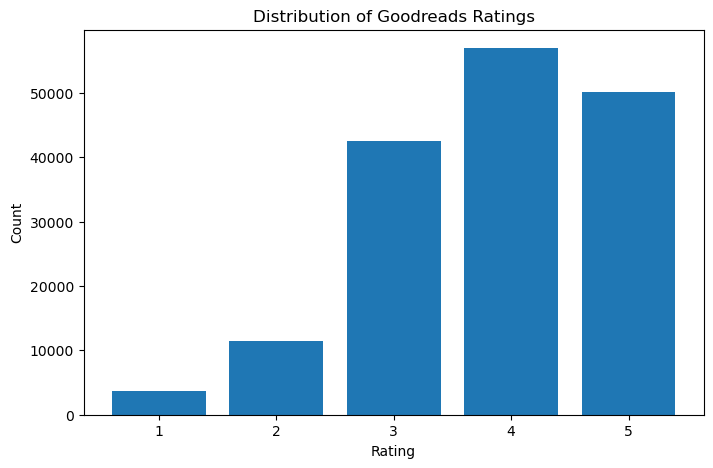

Average rating: 3.84
Median rating: 4.00
Share of ratings that are 4 or 5 stars: 65.0%
Share of ratings that are 1 or 2 stars: 9.2%
Insight: Ratings are skewed positive. This matters because a simple mean/bias baseline can perform well when most users give relatively high ratings.


In [155]:
###############################################################
# 7. RATING DISTRIBUTION AND POSITIVITY BIAS
###############################################################

rating_distribution = (
    ratings_clean[rating_col]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ["Rating", "Count"]
rating_distribution["Percent"] = rating_distribution["Count"] / rating_distribution["Count"].sum()
rating_distribution["Percent Display"] = rating_distribution["Percent"].map(lambda x: f"{x:.1%}")

display(rating_distribution)

plt.figure(figsize=(8, 5))
plt.bar(rating_distribution["Rating"], rating_distribution["Count"])
plt.title("Distribution of Goodreads Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rating_distribution["Rating"])
plt.show()

positive_share = (ratings_clean[rating_col] >= 4).mean()
negative_share = (ratings_clean[rating_col] <= 2).mean()
mean_rating = ratings_clean[rating_col].mean()
median_rating = ratings_clean[rating_col].median()

print(f"Average rating: {mean_rating:.2f}")
print(f"Median rating: {median_rating:.2f}")
print(f"Share of ratings that are 4 or 5 stars: {positive_share:.1%}")
print(f"Share of ratings that are 1 or 2 stars: {negative_share:.1%}")

print(
    "Insight: Ratings are skewed positive. This matters because a simple "
    "mean/bias baseline can perform well when most users give relatively high ratings."
)

,Ratings Given Summary
count,"1,192.0000"
mean,138.1946
std,30.9134
min,100.0000
25%,112.0000
50%,129.0000
75%,166.0000
max,200.0000


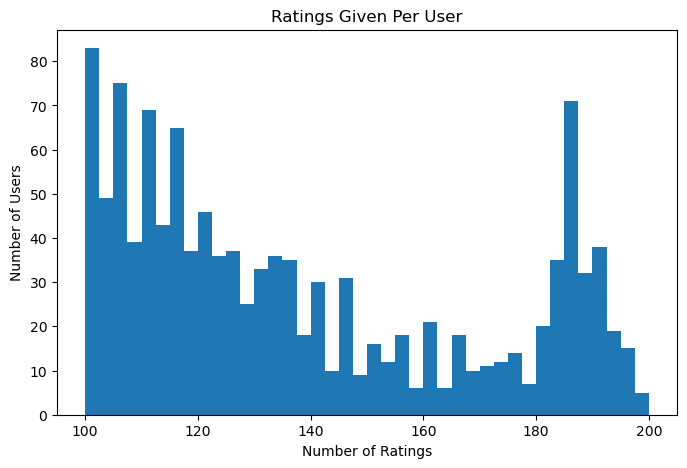

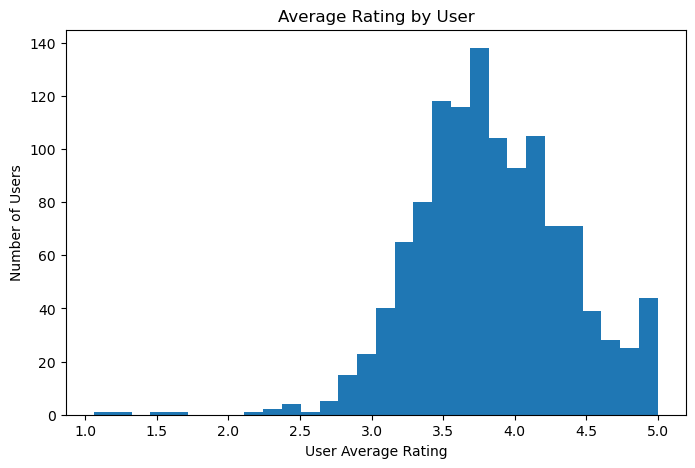

,Finding,Modeling Implication
0,Users vary in how many ratings they provide,Collaborative filtering will work better for u...
1,A small group of power users contributes a lar...,Power users provide stronger similarity signal...
2,Some users have limited rating history,Cold-start or low-activity users may need popu...


Top 10% most active users contribute 15.3% of all ratings.
Insight: Active users provide stronger collaborative-filtering signals, while low-activity users create a cold-start challenge.


In [156]:
# 8. USER ACTIVITY ANALYSIS

# Summary statistics for number of ratings per user
user_activity_summary = user_activity_df["ratings_given"].describe().to_frame("Ratings Given Summary")
display(user_activity_summary)

# Distribution of rating volume per user
plt.figure(figsize=(8, 5))
plt.hist(user_activity_df["ratings_given"], bins=40)
plt.title("Ratings Given Per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

# Distribution of average rating behavior per user
plt.figure(figsize=(8, 5))
plt.hist(user_activity_df["avg_rating"], bins=30)
plt.title("Average Rating by User")
plt.xlabel("User Average Rating")
plt.ylabel("Number of Users")
plt.show()

# Power-user concentration
top_10pct_users = user_activity_df["ratings_given"].quantile(0.90)

power_user_share = (
    user_activity_df.loc[
        user_activity_df["ratings_given"] >= top_10pct_users,
        "ratings_given"
    ].sum()
    / user_activity_df["ratings_given"].sum()
)

user_activity_insights = pd.DataFrame({
    "Finding": [
        "Users vary in how many ratings they provide",
        "A small group of power users contributes a large share of ratings",
        "Some users have limited rating history"
    ],
    "Modeling Implication": [
        "Collaborative filtering will work better for users with more historical ratings.",
        "Power users provide stronger similarity signals for neighborhood-based models.",
        "Cold-start or low-activity users may need popularity-based or hybrid recommendations."
    ]
})

display(user_activity_insights)

print(f"Top 10% most active users contribute {power_user_share:.1%} of all ratings.")
print(
    "Insight: Active users provide stronger collaborative-filtering signals, "
    "while low-activity users create a cold-start challenge."
)

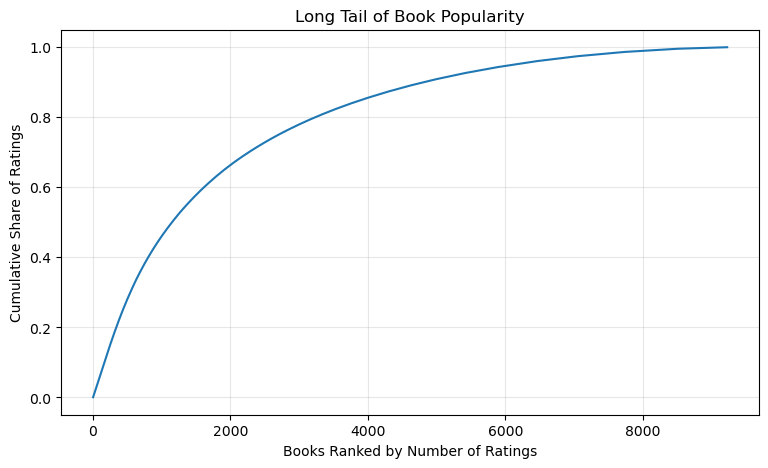

,Book Segment,Share of All Ratings
0,Top 1% most-rated books,5.6%
1,Top 5% most-rated books,26.3%
2,Top 10% most-rated books,43.8%


Insight: Book engagement follows a long-tail pattern. A small share of books receives a large share of ratings, which creates popularity bias risk. This helps explain why popularity-based baselines can be strong but may reduce discovery.


In [157]:
###############################################################
# 9. BOOK POPULARITY AND LONG-TAIL ANALYSIS
###############################################################

book_popularity = (
    ratings_clean
    .groupby(rating_book_col)
    .size()
    .sort_values(ascending=False)
)

cumulative_share = book_popularity.cumsum() / book_popularity.sum()

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_share) + 1), cumulative_share.values)
plt.title("Long Tail of Book Popularity")
plt.xlabel("Books Ranked by Number of Ratings")
plt.ylabel("Cumulative Share of Ratings")
plt.grid(True, alpha=0.3)
plt.show()

top_1pct = max(1, int(len(book_popularity) * 0.01))
top_5pct = max(1, int(len(book_popularity) * 0.05))
top_10pct = max(1, int(len(book_popularity) * 0.10))

popularity_concentration = pd.DataFrame({
    "Book Segment": [
        "Top 1% most-rated books",
        "Top 5% most-rated books",
        "Top 10% most-rated books"
    ],
    "Share of All Ratings": [
        book_popularity.iloc[:top_1pct].sum() / book_popularity.sum(),
        book_popularity.iloc[:top_5pct].sum() / book_popularity.sum(),
        book_popularity.iloc[:top_10pct].sum() / book_popularity.sum()
    ]
})

popularity_concentration["Share of All Ratings"] = popularity_concentration["Share of All Ratings"].map(
    lambda x: f"{x:.1%}"
)

display(popularity_concentration)

print(
    "Insight: Book engagement follows a long-tail pattern. A small share of books "
    "receives a large share of ratings, which creates popularity bias risk. "
    "This helps explain why popularity-based baselines can be strong but may reduce discovery."
)

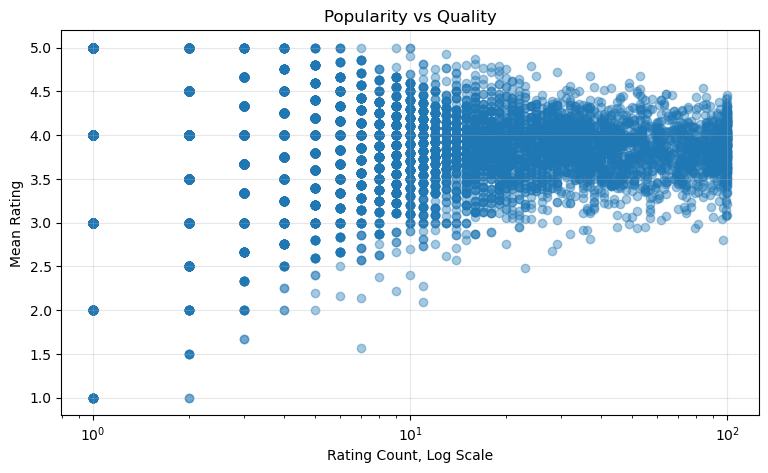

Correlation between book popularity and mean rating: 0.011


,Finding,Modeling Implication
0,Some books are popular because many users rate...,A popularity recommender may surface familiar ...
1,Some books are high-quality because users rate...,A mean-rating recommender may overvalue books ...
2,Popularity and quality are related but not ide...,A strong recommendation system should balance ...


Insight: Popularity and average rating are not the same thing. This justifies comparing collaborative filtering against both mean/bias and popularity-based baselines.


In [158]:
# 10. POPULARITY VS QUALITY


plt.figure(figsize=(9, 5))
plt.scatter(
    book_quality["rating_count"],
    book_quality["mean_rating"],
    alpha=0.4
)
plt.xscale("log")
plt.title("Popularity vs Quality")
plt.xlabel("Rating Count, Log Scale")
plt.ylabel("Mean Rating")
plt.grid(True, alpha=0.3)
plt.show()

corr_pop_quality = book_quality["rating_count"].corr(book_quality["mean_rating"])

print(f"Correlation between book popularity and mean rating: {corr_pop_quality:.3f}")

popularity_quality_interpretation = pd.DataFrame({
    "Finding": [
        "Some books are popular because many users rated them",
        "Some books are high-quality because users rate them highly",
        "Popularity and quality are related but not identical"
    ],
    "Modeling Implication": [
        "A popularity recommender may surface familiar books but not necessarily the best-fit books.",
        "A mean-rating recommender may overvalue books with few ratings unless rating count is considered.",
        "A strong recommendation system should balance rating volume, rating quality, and personalization."
    ]
})

display(popularity_quality_interpretation)

print(
    "Insight: Popularity and average rating are not the same thing. "
    "This justifies comparing collaborative filtering against both mean/bias "
    "and popularity-based baselines."
)

Book Cold-Start Risk


,Threshold,Share of Books
0,<=1,8.3%
1,<=3,24.1%
2,<=5,36.7%
3,<=10,57.1%
4,<=20,74.9%


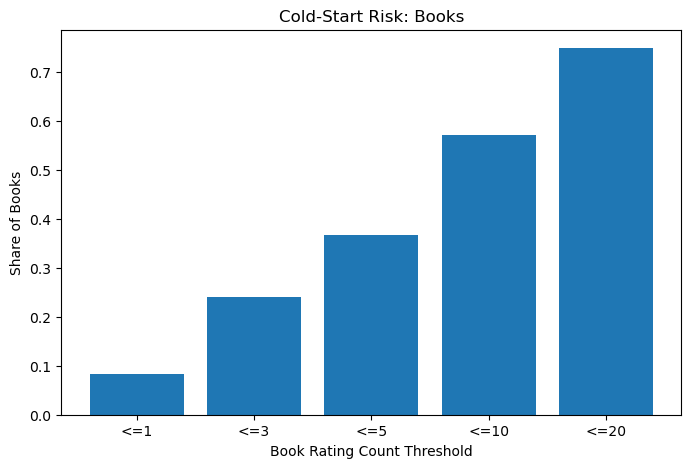

User Rating Count Summary


count   1,192.0000
mean      138.1946
std        30.9134
min       100.0000
25%       112.0000
50%       129.0000
75%       166.0000
max       200.0000
Name: ratings_given, dtype: float64

User Activity Thresholds


,Threshold,Share of Users
0,<=100,2.6%
1,<=112,26.4%
2,<=129,50.7%
3,<=166,75.3%


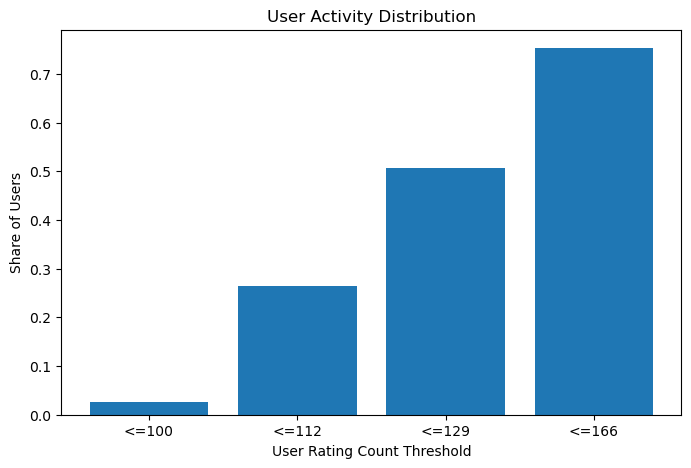

,Area,Finding,Recommendation Implication
0,Rarely rated books,36.7% of books have five or fewer ratings.,"Use popularity, metadata, or LLM context to su..."
1,Low-activity users,"The minimum user rating count is 100, suggesti...",User-based methods have more user history avai...
2,Dataset structure,The dataset appears more filtered on the user ...,Book-level sparsity remains important even whe...
3,Model selection implication,Pure collaborative filtering may struggle for ...,A hybrid pipeline is appropriate: collaborativ...


Insight: 36.7% of books have five or fewer ratings, while the least-active user has 100 ratings. This suggests that book cold-start risk is more important than user cold-start risk in this dataset.


In [159]:
###############################################################
# 11. COLD-START RISK
###############################################################

# -------------------------------------------------------------
# 11A. BOOK COLD-START RISK
# -------------------------------------------------------------
# Books with very few ratings are difficult for collaborative filtering
# because the model has limited evidence to learn item similarity.

book_thresholds = [1, 3, 5, 10, 20]

book_cold_start = pd.DataFrame({
    "Threshold": [f"<={x}" for x in book_thresholds],
    "Share of Books": [
        (book_quality["rating_count"] <= x).mean()
        for x in book_thresholds
    ]
})

book_cold_start_display = book_cold_start.copy()
book_cold_start_display["Share of Books"] = book_cold_start_display["Share of Books"].map(
    lambda x: f"{x:.1%}"
)

print("Book Cold-Start Risk")
display(book_cold_start_display)

plt.figure(figsize=(8, 5))
plt.bar(
    book_cold_start["Threshold"],
    book_cold_start["Share of Books"]
)
plt.title("Cold-Start Risk: Books")
plt.xlabel("Book Rating Count Threshold")
plt.ylabel("Share of Books")
plt.show()


# -------------------------------------------------------------
# 11B. USER COLD-START / USER ACTIVITY RISK
# -------------------------------------------------------------
# The dataset may already be filtered toward active users.
# Therefore, fixed low thresholds like <=1 or <=5 may show 0%.
# Use data-appropriate thresholds based on the observed distribution.

print("User Rating Count Summary")
display(user_activity_df["ratings_given"].describe())

min_user_ratings = int(user_activity_df["ratings_given"].min())
q25_user_ratings = int(user_activity_df["ratings_given"].quantile(0.25))
median_user_ratings = int(user_activity_df["ratings_given"].median())
q75_user_ratings = int(user_activity_df["ratings_given"].quantile(0.75))

user_thresholds = sorted(set([
    min_user_ratings,
    q25_user_ratings,
    median_user_ratings,
    q75_user_ratings
]))

user_activity_thresholds = pd.DataFrame({
    "Threshold": [f"<={x}" for x in user_thresholds],
    "Share of Users": [
        (user_activity_df["ratings_given"] <= x).mean()
        for x in user_thresholds
    ]
})

user_activity_thresholds_display = user_activity_thresholds.copy()
user_activity_thresholds_display["Share of Users"] = user_activity_thresholds_display["Share of Users"].map(
    lambda x: f"{x:.1%}"
)

print("User Activity Thresholds")
display(user_activity_thresholds_display)

plt.figure(figsize=(8, 5))
plt.bar(
    user_activity_thresholds["Threshold"],
    user_activity_thresholds["Share of Users"]
)
plt.title("User Activity Distribution")
plt.xlabel("User Rating Count Threshold")
plt.ylabel("Share of Users")
plt.show()


# -------------------------------------------------------------
# 11C. MODELING IMPLICATIONS
# -------------------------------------------------------------

book_low_rating_share = (book_quality["rating_count"] <= 5).mean()
user_low_activity_share = (user_activity_df["ratings_given"] <= min_user_ratings).mean()

cold_start_implications = pd.DataFrame({
    "Area": [
        "Rarely rated books",
        "Low-activity users",
        "Dataset structure",
        "Model selection implication"
    ],
    "Finding": [
        f"{book_low_rating_share:.1%} of books have five or fewer ratings.",
        f"The minimum user rating count is {min_user_ratings}, suggesting users are relatively active.",
        "The dataset appears more filtered on the user side than the book side.",
        "Pure collaborative filtering may struggle for rarely rated books, while user cold-start risk is less severe in this dataset."
    ],
    "Recommendation Implication": [
        "Use popularity, metadata, or LLM context to support recommendations for low-signal books.",
        "User-based methods have more user history available than a true cold-start setting.",
        "Book-level sparsity remains important even when users are active.",
        "A hybrid pipeline is appropriate: collaborative filtering for candidates, LLM re-ranking for context and explanation."
    ]
})

display(cold_start_implications)

print(
    f"Insight: {book_low_rating_share:.1%} of books have five or fewer ratings, "
    f"while the least-active user has {min_user_ratings} ratings. "
    "This suggests that book cold-start risk is more important than user cold-start risk in this dataset."
)

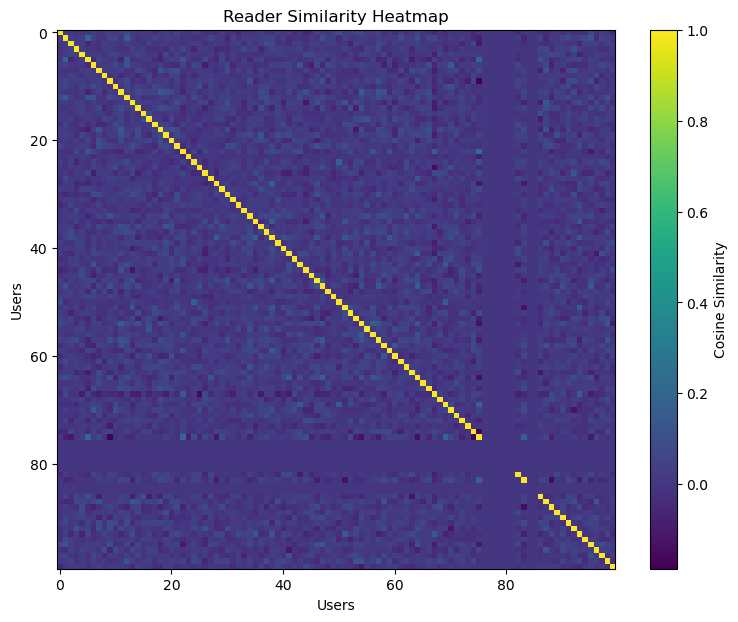

,Metric,Value
0,Number of sampled users,100
1,Number of books in similarity matrix,3475
2,Average reader similarity,0.010
3,Median reader similarity,0.002
4,Minimum reader similarity,-0.186
5,Maximum reader similarity,0.234


Insight: Reader similarity is useful for evaluating whether user-based collaborative filtering has enough overlap to identify similar readers. Low average similarity would suggest that item-based CF or matrix factorization may be more stable than user-based nearest-neighbor models.


In [160]:
###############################################################
# 12. READER SIMILARITY HEATMAP
###############################################################

# Select the most active users because they provide the strongest rating signals
sample_users = (
    user_activity_df
    .sort_values("ratings_given", ascending=False)
    .head(min(100, len(user_activity_df)))[user_col]
)

sample_ratings = ratings_clean[
    ratings_clean[user_col].isin(sample_users)
].copy()

# Create user-book matrix
# Rows = users, columns = books, values = ratings
reader_matrix_raw = sample_ratings.pivot_table(
    index=user_col,
    columns=rating_book_col,
    values=rating_col
)

# Center ratings by each user's average rating
# This reduces bias from users who rate everything high or low
reader_matrix_centered = reader_matrix_raw.sub(
    reader_matrix_raw.mean(axis=1),
    axis=0
)

# Fill missing ratings with 0 after centering
# In this centered matrix, 0 means "no observed preference deviation"
reader_matrix_centered = reader_matrix_centered.fillna(0)

# Compute cosine similarity between users
reader_similarity = cosine_similarity(reader_matrix_centered)

plt.figure(figsize=(9, 7))
plt.imshow(reader_similarity, aspect="auto")
plt.colorbar(label="Cosine Similarity")
plt.title("Reader Similarity Heatmap")
plt.xlabel("Users")
plt.ylabel("Users")
plt.show()

# Extract off-diagonal similarity values
if reader_similarity.shape[0] > 1:
    upper_triangle = reader_similarity[np.triu_indices_from(reader_similarity, k=1)]

    avg_similarity = upper_triangle.mean()
    median_similarity = np.median(upper_triangle)
    max_similarity = upper_triangle.max()
    min_similarity = upper_triangle.min()

    similarity_summary = pd.DataFrame({
        "Metric": [
            "Number of sampled users",
            "Number of books in similarity matrix",
            "Average reader similarity",
            "Median reader similarity",
            "Minimum reader similarity",
            "Maximum reader similarity"
        ],
        "Value": [
            reader_matrix_centered.shape[0],
            reader_matrix_centered.shape[1],
            f"{avg_similarity:.3f}",
            f"{median_similarity:.3f}",
            f"{min_similarity:.3f}",
            f"{max_similarity:.3f}"
        ]
    })

    display(similarity_summary)

    print(
        "Insight: Reader similarity is useful for evaluating whether user-based "
        "collaborative filtering has enough overlap to identify similar readers. "
        "Low average similarity would suggest that item-based CF or matrix factorization "
        "may be more stable than user-based nearest-neighbor models."
    )

else:
    print("Not enough users to compute reader similarity.")

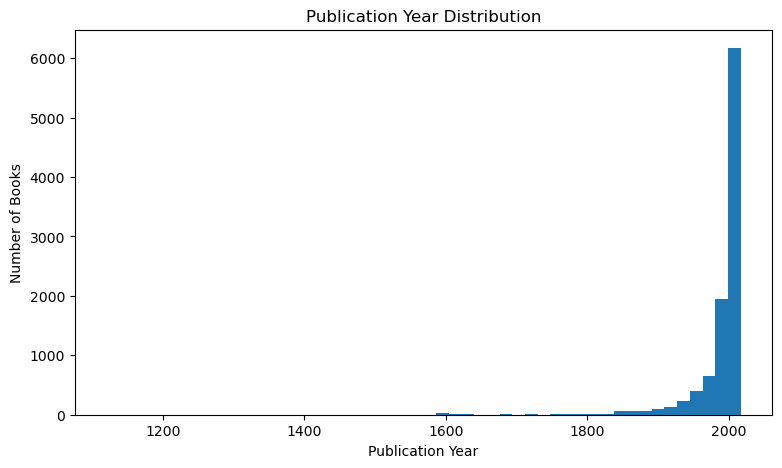

Median publication year: 2004
Share of books published in 2000 or later: 62.3%
Top Authors by Number of Books


,Book Count
authors,
Stephen King,60
Nora Roberts,58
Dean Koontz,47
Terry Pratchett,42
Agatha Christie,39
Meg Cabot,37
James Patterson,36
David Baldacci,34
John Grisham,33


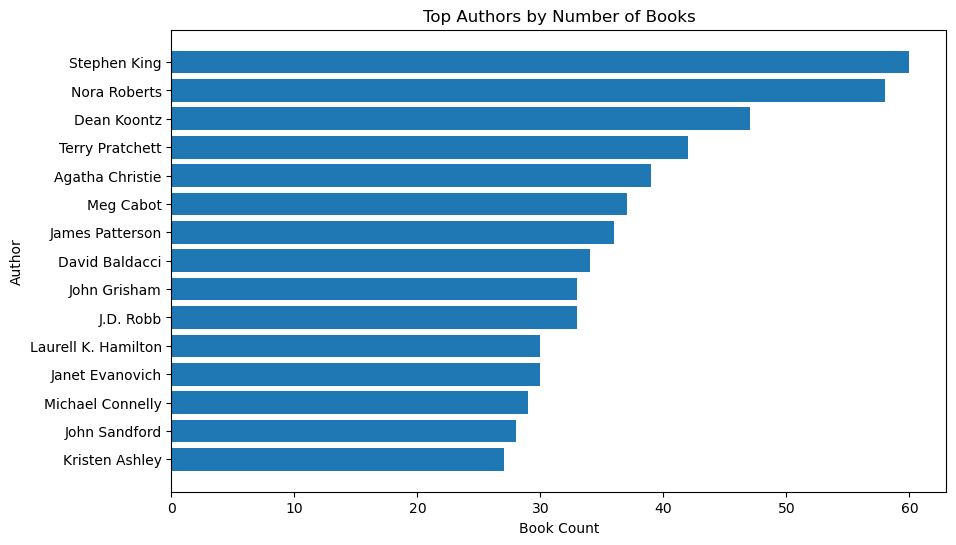

Top Languages in Dataset


,Book Count
language_code,
eng,6322
en-US,2062
Missing,1076
en-GB,256
ara,64
en-CA,58
fre,25
ind,21
spa,20


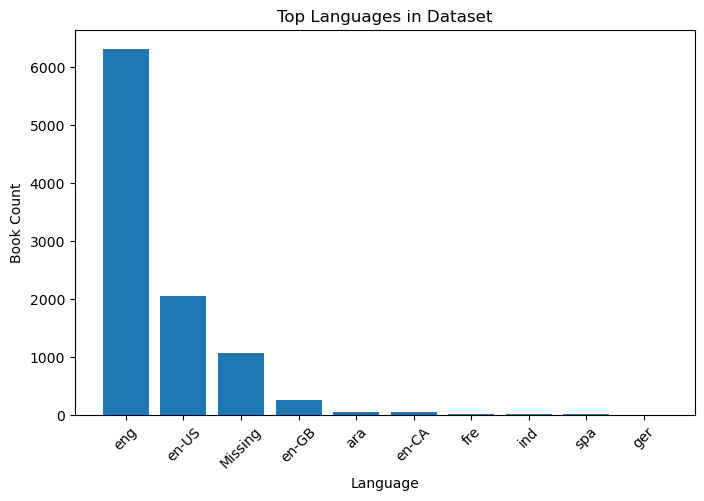

,Metadata Area,Finding,Recommendation Implication
0,Publication year,Median publication year is 2004; 62.3% of book...,Publication year can influence reading prefere...
1,Author,The most frequent author entry is 'Stephen Kin...,"Author information can support explanation, fi..."
2,Language,The most common language is 'eng' with 6322 bo...,Language can affect recommendation relevance a...


In [161]:
###############################################################
# 13. BOOK METADATA EXPLORATION
###############################################################

metadata_findings = []

# -------------------------------------------------------------
# 13A. PUBLICATION YEAR DISTRIBUTION
# -------------------------------------------------------------

if year_col is not None:
    books_clean[year_col] = pd.to_numeric(
        books_clean[year_col],
        errors="coerce"
    )

    valid_years = books_clean[
        books_clean[year_col].between(1000, 2026)
    ][year_col]

    if len(valid_years) > 0:
        plt.figure(figsize=(9, 5))
        plt.hist(valid_years, bins=50)
        plt.title("Publication Year Distribution")
        plt.xlabel("Publication Year")
        plt.ylabel("Number of Books")
        plt.show()

        median_year = valid_years.median()
        modern_share = (valid_years >= 2000).mean()

        print(f"Median publication year: {median_year:.0f}")
        print(f"Share of books published in 2000 or later: {modern_share:.1%}")

        metadata_findings.append({
            "Metadata Area": "Publication year",
            "Finding": f"Median publication year is {median_year:.0f}; {modern_share:.1%} of books were published in 2000 or later.",
            "Recommendation Implication": "Publication year can influence reading preferences and may be useful for personalization."
        })
    else:
        print("No valid publication years available.")

else:
    print("No publication year column found.")


# -------------------------------------------------------------
# 13B. AUTHOR DISTRIBUTION
# -------------------------------------------------------------

if author_col is not None:
    top_authors = (
        books_clean[author_col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .head(15)
    )

    print("Top Authors by Number of Books")
    display(top_authors.to_frame("Book Count"))

    plt.figure(figsize=(10, 6))
    plt.barh(top_authors.index, top_authors.values)
    plt.title("Top Authors by Number of Books")
    plt.xlabel("Book Count")
    plt.ylabel("Author")
    plt.gca().invert_yaxis()
    plt.show()

    top_author = top_authors.index[0]
    top_author_count = top_authors.iloc[0]

    metadata_findings.append({
        "Metadata Area": "Author",
        "Finding": f"The most frequent author entry is '{top_author}' with {top_author_count} books.",
        "Recommendation Implication": "Author information can support explanation, filtering, and user-facing personalization."
    })

else:
    print("No author column found.")


# -------------------------------------------------------------
# 13C. LANGUAGE DISTRIBUTION
# -------------------------------------------------------------

if language_col is not None:
    top_languages = (
        books_clean[language_col]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .head(10)
    )

    print("Top Languages in Dataset")
    display(top_languages.to_frame("Book Count"))

    plt.figure(figsize=(8, 5))
    plt.bar(top_languages.index, top_languages.values)
    plt.title("Top Languages in Dataset")
    plt.xlabel("Language")
    plt.ylabel("Book Count")
    plt.xticks(rotation=45)
    plt.show()

    top_language = top_languages.index[0]
    top_language_count = top_languages.iloc[0]

    metadata_findings.append({
        "Metadata Area": "Language",
        "Finding": f"The most common language is '{top_language}' with {top_language_count} books.",
        "Recommendation Implication": "Language can affect recommendation relevance and should be considered in user-facing filters."
    })

else:
    print("No language column found.")


# -------------------------------------------------------------
# 13D. METADATA SUMMARY
# -------------------------------------------------------------

metadata_findings_df = pd.DataFrame(metadata_findings)

if len(metadata_findings_df) > 0:
    display(metadata_findings_df)
else:
    print("No metadata findings were generated because relevant metadata columns were unavailable.")

In [162]:
###############################################################
# 14. HIDDEN GEMS AND TOP BOOKS
###############################################################

# Columns to display safely
display_cols = [book_id_col, title_col]

if author_col is not None:
    display_cols.append(author_col)

display_cols += ["rating_count", "mean_rating"]


# -------------------------------------------------------------
# 14A. HIDDEN GEMS
# -------------------------------------------------------------
# Hidden gems are books with strong ratings but lower visibility.
# These are useful because a recommender should not only surface obvious bestsellers.

hidden_gems = (
    book_quality[
        (book_quality["rating_count"] >= 20) &
        (book_quality["rating_count"] <= book_quality["rating_count"].quantile(0.75)) &
        (book_quality["mean_rating"] >= 4.2)
    ]
    .sort_values(["mean_rating", "rating_count"], ascending=[False, False])
    .head(15)
)

print("Hidden gems: high-rated books with lower visibility")

if len(hidden_gems) > 0:
    display(hidden_gems[display_cols])
else:
    print("No hidden gems found using the current thresholds.")


# -------------------------------------------------------------
# 14B. MOST RATED BOOKS
# -------------------------------------------------------------
# These books represent popularity and visibility.

most_rated_books = (
    book_quality
    .sort_values("rating_count", ascending=False)
    .head(15)
)

print("Most rated books")
display(most_rated_books[display_cols])


# -------------------------------------------------------------
# 14C. HIGHEST-RATED BOOKS WITH MINIMUM SUPPORT
# -------------------------------------------------------------
# Minimum support prevents books with only a few ratings from dominating.

highest_rated_books = (
    book_quality[book_quality["rating_count"] >= 25]
    .sort_values("mean_rating", ascending=False)
    .head(15)
)

print("Highest rated books with at least 25 ratings")

if len(highest_rated_books) > 0:
    display(highest_rated_books[display_cols])
else:
    print("No books found with at least 25 ratings.")


# -------------------------------------------------------------
# 14D. INTERPRETATION
# -------------------------------------------------------------

hidden_gem_summary = pd.DataFrame({
    "Analysis": [
        "Most rated books",
        "Highest-rated books",
        "Hidden gems"
    ],
    "What It Shows": [
        "Which books dominate user attention and may be favored by popularity-based recommenders.",
        "Which books have the strongest average ratings after applying minimum support.",
        "Which books combine high satisfaction with lower visibility."
    ],
    "Recommendation Implication": [
        "Useful as a simple benchmark but may reduce discovery.",
        "Useful for quality-aware ranking but can still ignore personalization.",
        "Useful for improving discovery beyond obvious bestsellers."
    ]
})

display(hidden_gem_summary)

print(
    "Insight: Popularity, quality, and discovery are different recommendation goals. "
    "This supports using collaborative filtering for personalization and the LLM layer "
    "to explain why selected books fit the user's stated preference."
)

Hidden gems: high-rated books with lower visibility


,book_id,title,authors,rating_count,mean_rating
343,1308,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,20,4.7500
2630,3396,Worlds' End (The Sandman #8),"Neil Gaiman, Mike Allred, Gary Amaro, Mark Buc...",20,4.6500
422,1380,"The Complete Maus (Maus, #1-2)",Art Spiegelman,21,4.6190
1485,2346,Columbine,Dave Cullen,21,4.6190
871,1788,The Calvin and Hobbes Tenth Anniversary Book,Bill Watterson,20,4.5500
4681,532,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",20,4.5500
456,1410,"The Murder of Roger Ackroyd (Hercule Poirot, #4)",Agatha Christie,21,4.5238
512,1461,The Memoirs of Sherlock Holmes,Arthur Conan Doyle,20,4.4500
813,1734,Endurance: Shackleton's Incredible Voyage,Alfred Lansing,20,4.4500
4050,4709,"Lyle, Lyle, Crocodile",Bernard Waber,20,4.4500


Most rated books


,book_id,title,authors,rating_count,mean_rating
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,100,4.2400
3827,45,Life of Pi,Yann Martel,100,3.9100
8522,919,The Shipping News,Annie Proulx,100,3.6800
345,131,The Grapes of Wrath,John Steinbeck,100,3.8900
3718,44,"The Notebook (The Notebook, #1)",Nicholas Sparks,100,3.2100
3610,43,Jane Eyre,"Charlotte BrontÃ«, Michael Mason",100,4.0500
3569,426,A Confederacy of Dunces,"John Kennedy Toole, Walker Percy",100,3.7700
3504,42,"Little Women (Little Women, #1)",Louisa May Alcott,100,4.1300
8627,93,The Secret Garden,Frances Hodgson Burnett,100,4.1100
367,133,"Anne of Green Gables (Anne of Green Gables, #1)",L.M. Montgomery,100,3.9600


Highest rated books with at least 25 ratings


,book_id,title,authors,rating_count,mean_rating
1304,2181,Tikki Tikki Tembo,"Arlene Mosel, Blair Lent",29,4.7241
1298,2176,The Cat in the Hat and Other Dr. Seuss Favorites,"Dr. Seuss, Various",25,4.6800
7994,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,53,4.6792
2885,3628,The Complete Calvin and Hobbes,Bill Watterson,37,4.6757
15,1010,The Essential Calvin and Hobbes: A Calvin and ...,Bill Watterson,49,4.5918
320,1287,"Miss Nelson Is Missing! (Miss Nelson, #1)","Harry Allard, James Marshall",32,4.5625
28,1022,"Heir of Fire (Throne of Glass, #3)",Sarah J. Maas,38,4.5526
1335,2209,The Complete Works,William Shakespeare,49,4.5510
1017,192,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,84,4.5357
724,1654,"Cold Days (The Dresden Files, #14)",Jim Butcher,43,4.5349


,Analysis,What It Shows,Recommendation Implication
0,Most rated books,Which books dominate user attention and may be...,Useful as a simple benchmark but may reduce di...
1,Highest-rated books,Which books have the strongest average ratings...,Useful for quality-aware ranking but can still...
2,Hidden gems,Which books combine high satisfaction with low...,Useful for improving discovery beyond obvious ...


Insight: Popularity, quality, and discovery are different recommendation goals. This supports using collaborative filtering for personalization and the LLM layer to explain why selected books fit the user's stated preference.


In [163]:
###############################################################
# 15. EDA-TO-MODELING IMPLICATIONS
###############################################################

eda_modeling_summary = pd.DataFrame({
    "EDA Finding": [
        "Sparse user-book matrix",
        "Ratings skew positive",
        "Power users exist",
        "Book popularity follows a long tail",
        "Popularity is not the same as quality",
        "Book cold-start risk is more important than user cold-start risk",
        "Reader similarity varies",
        "Metadata shows catalog structure",
        "Hidden gems exist"
    ],
    "Why It Matters for Modeling": [
        "Neighborhood-based collaborative filtering may struggle because many users/books have limited overlap.",
        "Mean/bias baselines may perform surprisingly well because many ratings are already high.",
        "Active users provide stronger collaborative-filtering signals than low-activity users.",
        "Popularity recommenders may dominate but reduce personalization and discovery.",
        "Recommending only popular books can miss niche high-quality books.",
        "Pure collaborative filtering may struggle for rarely rated books, even if users have enough history.",
        "Similarity structure affects whether user-based or item-based collaborative filtering works better.",
        "Author, year, and language patterns may influence recommendation diversity and explanation quality.",
        "A recommender can create value by surfacing strong books beyond obvious bestsellers."
    ],
    "How This Informs the Recommender": [
        "Compare neighborhood-based CF with matrix factorization and baselines.",
        "Include a strong mean/bias baseline.",
        "Use active-user histories to generate collaborative-filtering candidates.",
        "Compare against a popularity baseline and watch for popularity bias.",
        "Use evaluation metrics beyond average rating alone.",
        "Use popularity, metadata, or LLM explanation support for low-signal books.",
        "Evaluate user-based and item-based CF separately.",
        "Pass book metadata into the LLM re-ranking layer.",
        "Consider discovery value, not just predicted rating."
    ]
})

display(eda_modeling_summary)

,EDA Finding,Why It Matters for Modeling,How This Informs the Recommender
0,Sparse user-book matrix,Neighborhood-based collaborative filtering may...,Compare neighborhood-based CF with matrix fact...
1,Ratings skew positive,Mean/bias baselines may perform surprisingly w...,Include a strong mean/bias baseline.
2,Power users exist,Active users provide stronger collaborative-fi...,Use active-user histories to generate collabor...
3,Book popularity follows a long tail,Popularity recommenders may dominate but reduc...,Compare against a popularity baseline and watc...
4,Popularity is not the same as quality,Recommending only popular books can miss niche...,Use evaluation metrics beyond average rating a...
5,Book cold-start risk is more important than us...,Pure collaborative filtering may struggle for ...,"Use popularity, metadata, or LLM explanation s..."
6,Reader similarity varies,Similarity structure affects whether user-base...,Evaluate user-based and item-based CF separately.
7,Metadata shows catalog structure,"Author, year, and language patterns may influe...",Pass book metadata into the LLM re-ranking layer.
8,Hidden gems exist,A recommender can create value by surfacing st...,"Consider discovery value, not just predicted r..."


In [164]:
###############################################################
# 16. SURPRISE DATASET SETUP
###############################################################

# Surprise requires a dataframe with exactly:
# user ID, item/book ID, rating
surprise_df = ratings_clean[[user_col, rating_book_col, rating_col]].copy()

# Confirm rating scale from the cleaned data
rating_min = float(surprise_df[rating_col].min())
rating_max = float(surprise_df[rating_col].max())

reader = Reader(rating_scale=(rating_min, rating_max))

data = Dataset.load_from_df(
    surprise_df,
    reader
)

# Hold-out split for model evaluation
trainset, testset = train_test_split(
    data,
    test_size=0.10,
    random_state=RANDOM_STATE
)

print("Surprise dataset created successfully.")
print(f"Train ratings: {trainset.n_ratings:,}")
print(f"Test ratings: {len(testset):,}")
print(f"Total ratings used: {trainset.n_ratings + len(testset):,}")
print(f"Test size: {len(testset) / (trainset.n_ratings + len(testset)):.1%}")
print(f"Rating scale: {rating_min} to {rating_max}")

Surprise dataset created successfully.
Train ratings: 148,255
Test ratings: 16,473
Total ratings used: 164,728
Test size: 10.0%
Rating scale: 1.0 to 5.0


In [165]:
###############################################################
# 17. PRECISION@K AND RECALL@K FUNCTION
###############################################################

def precision_recall_at_k(predictions, k=10, threshold=4.0):
    """
    Computes Precision@K and Recall@K from Surprise predictions.

    Parameters:
    predictions : list
        Surprise prediction objects returned by model.test(testset).
    k : int
        Number of top recommendations to evaluate.
    threshold : float
        Minimum true rating required for an item to be considered relevant.

    Returns:
    precision : float
        Average share of Top-K recommendations that are relevant.
    recall : float
        Average share of relevant items captured in the Top-K recommendations.
    """

    # Store estimated and true ratings by user
    user_est_true = defaultdict(list)

    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = []
    recalls = []

    for uid, user_ratings in user_est_true.items():

        # Rank items for each user by predicted rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        top_k = user_ratings[:k]

        # Number of truly relevant items in this user's test set
        n_relevant = sum(true_r >= threshold for _, true_r in user_ratings)

        # Number of recommended items in Top-K that are truly relevant
        n_recommended_relevant = sum(true_r >= threshold for _, true_r in top_k)

        # Use len(top_k) in case the user has fewer than k test observations
        precision = (
            n_recommended_relevant / len(top_k)
            if len(top_k) > 0
            else 0
        )

        recall = (
            n_recommended_relevant / n_relevant
            if n_relevant > 0
            else 0
        )

        precisions.append(precision)
        recalls.append(recall)

    return float(np.mean(precisions)), float(np.mean(recalls))

In [166]:
###############################################################
# 18. POPULARITY BASELINE RECOMMENDER
###############################################################

def build_popularity_scores(ratings_df, min_ratings=20):
    """
    Builds a simple popularity/mean baseline recommender.

    The weighted score balances:
    - Mean rating
    - Number of ratings
    - Global average rating

    This prevents books with only a few high ratings from dominating.
    """

    book_scores = (
        ratings_df
        .groupby(rating_book_col)
        .agg(
            rating_count=(rating_col, "count"),
            mean_rating=(rating_col, "mean")
        )
        .reset_index()
    )

    global_mean = ratings_df[rating_col].mean()

    book_scores["weighted_score"] = (
        (book_scores["rating_count"] / (book_scores["rating_count"] + min_ratings))
        * book_scores["mean_rating"]
        +
        (min_ratings / (book_scores["rating_count"] + min_ratings))
        * global_mean
    )

    book_scores = book_scores.sort_values(
        "weighted_score",
        ascending=False
    )

    return book_scores


popularity_scores = build_popularity_scores(
    ratings_clean,
    min_ratings=20
)

# Add book metadata for readability
popularity_scores_display = popularity_scores.copy()
popularity_scores_display[rating_book_col] = popularity_scores_display[rating_book_col].astype(str)

book_meta_display = book_meta.copy()
book_meta_display[book_id_col] = book_meta_display[book_id_col].astype(str)

popularity_scores_display = popularity_scores_display.rename(
    columns={rating_book_col: book_id_col}
)

popularity_scores_display = popularity_scores_display.merge(
    book_meta_display,
    on=book_id_col,
    how="left"
)

print("Top books from popularity/weighted-mean baseline:")

display_cols = [book_id_col, title_col]

if author_col is not None:
    display_cols.append(author_col)

display_cols += ["rating_count", "mean_rating", "weighted_score"]

display(popularity_scores_display[display_cols].head(10))

Top books from popularity/weighted-mean baseline:


,book_id,title,authors,rating_count,mean_rating,weighted_score
0,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,53,4.6792,4.4495
1,192,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,84,4.5357,4.4020
2,3628,The Complete Calvin and Hobbes,Bill Watterson,37,4.6757,4.3826
3,1010,The Essential Calvin and Hobbes: A Calvin and ...,Bill Watterson,49,4.5918,4.3741
4,2181,Tikki Tikki Tembo,"Arlene Mosel, Blair Lent",29,4.7241,4.3635
5,4653,The Complete Novels,Jane Austen,24,4.7917,4.3593
6,4,To Kill a Mockingbird,Harper Lee,100,4.4600,4.3567
7,2209,The Complete Works,William Shakespeare,49,4.5510,4.3451
8,1342,"Night Watch (Discworld, #29; City Watch, #6)",Terry Pratchett,53,4.5283,4.3399
9,39,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,100,4.4200,4.3234


In [167]:
# POPULARITY BASELINE TOP-N EVALUATION

def evaluate_popularity_baseline_top_n(
    trainset,
    testset,
    popularity_scores,
    k=10,
    threshold=4.0
):
    """
    Evaluates a popularity-based Top-N recommender.

    Logic:
    - Recommend globally popular/high-rated books.
    - Remove books the user already rated in training.
    - Compare recommendations against relevant books in the held-out test set.
    """

    # Convert Surprise trainset back to raw user/book IDs
    train_user_items = defaultdict(set)

    for inner_uid in trainset.all_users():
        raw_uid = trainset.to_raw_uid(inner_uid)

        for inner_iid, _ in trainset.ur[inner_uid]:
            raw_iid = trainset.to_raw_iid(inner_iid)
            train_user_items[str(raw_uid)].add(str(raw_iid))

    # Test relevant items by user
    test_relevant = defaultdict(set)

    for uid, iid, true_r in testset:
        if true_r >= threshold:
            test_relevant[str(uid)].add(str(iid))

    ranked_books = popularity_scores[rating_book_col].astype(str).tolist()

    precisions = []
    recalls = []

    for uid, relevant_items in test_relevant.items():
        already_rated = train_user_items.get(str(uid), set())

        recs = [
            book_id
            for book_id in ranked_books
            if book_id not in already_rated
        ][:k]

        hits = len(set(recs) & relevant_items)

        precision = hits / k
        recall = hits / len(relevant_items) if len(relevant_items) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return float(np.mean(precisions)), float(np.mean(recalls))


pop_precision_10, pop_recall_10 = evaluate_popularity_baseline_top_n(
    trainset=trainset,
    testset=testset,
    popularity_scores=popularity_scores,
    k=10,
    threshold=4.0
)

popularity_eval = pd.DataFrame({
    "Model": ["Popularity Baseline"],
    "RMSE": [np.nan],
    "Precision@10": [pop_precision_10],
    "Recall@10": [pop_recall_10]
})

display(popularity_eval.round(4))

,Model,RMSE,Precision@10,Recall@10
0,Popularity Baseline,NaN,0.0061,0.0066


In [168]:
full_results_df = pd.concat(
    [results_df, popularity_eval],
    ignore_index=True
)

full_results_df = full_results_df.sort_values(
    ["Precision@10", "Recall@10", "RMSE"],
    ascending=[False, False, True],
    na_position="last"
).reset_index(drop=True)

display(full_results_df.round(4))

print(
    "Interpretation: This table compares personalized collaborative-filtering models "
    "against the non-personalized popularity baseline. RMSE applies to the Surprise "
    "rating-prediction models, while Precision@10 and Recall@10 evaluate Top-N "
    "recommendation quality."
)

,Model,RMSE,Precision@10,Recall@10
0,User-Based CF - Pearson,0.9871,0.6847,0.7964
1,Baseline Mean/Bias,0.8410,0.6816,0.7923
2,SVD Matrix Factorization,0.8399,0.6799,0.7899
3,User-Based CF - Cosine,0.9892,0.6791,0.7884
4,Item-Based CF - Pearson,0.8656,0.6722,0.7806
5,Item-Based CF - Cosine,0.8679,0.6558,0.7609
6,Popularity Baseline,NaN,0.0061,0.0066


Interpretation: This table compares personalized collaborative-filtering models against the non-personalized popularity baseline. RMSE applies to the Surprise rating-prediction models, while Precision@10 and Recall@10 evaluate Top-N recommendation quality.


In [169]:
###############################################################
# 20. MODEL TRAINING AND EVALUATION
###############################################################

# A rating is considered relevant for Top-N evaluation if it is 4 stars or higher
threshold = 4.0

models = {
    "Baseline Mean/Bias": BaselineOnly(verbose=False),

    "User-Based CF - Cosine": KNNBasic(
        k=30,
        min_k=3,
        sim_options={"name": "cosine", "user_based": True},
        verbose=False
    ),

    "User-Based CF - Pearson": KNNBasic(
        k=50,
        min_k=3,
        sim_options={"name": "pearson", "user_based": True},
        verbose=False
    ),

    "Item-Based CF - Cosine": KNNBasic(
        k=50,
        min_k=3,
        sim_options={"name": "cosine", "user_based": False},
        verbose=False
    ),

    "Item-Based CF - Pearson": KNNBasic(
        k=50,
        min_k=3,
        sim_options={"name": "pearson", "user_based": False},
        verbose=False
    ),

    "SVD Matrix Factorization": SVD(
        n_factors=80,
        n_epochs=25,
        lr_all=0.005,
        reg_all=0.08,
        random_state=RANDOM_STATE
    )
}

results = []
fitted_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    # Train model on training set
    model.fit(trainset)

    # Predict ratings on hold-out test set
    predictions = model.test(testset)

    # Rating-prediction metric
    rmse = accuracy.rmse(predictions, verbose=False)

    # Top-N ranking metrics
    precision_10, recall_10 = precision_recall_at_k(
        predictions,
        k=10,
        threshold=threshold
    )

    results.append({
        "Model": model_name,
        "RMSE": rmse,
        "Precision@10": precision_10,
        "Recall@10": recall_10
    })

    fitted_models[model_name] = model

# RMSE-oriented view
results_df = (
    pd.DataFrame(results)
    .sort_values(["RMSE", "Precision@10"], ascending=[True, False])
    .reset_index(drop=True)
)

print("Model results sorted by RMSE:")
display(results_df.round(4))

# Ranking-oriented view
ranking_results_df = (
    pd.DataFrame(results)
    .sort_values(["Precision@10", "Recall@10", "RMSE"], ascending=[False, False, True])
    .reset_index(drop=True)
)

print("Model results sorted by Precision@10 and Recall@10:")
display(ranking_results_df.round(4))

Training: Baseline Mean/Bias
Training: User-Based CF - Cosine
Training: User-Based CF - Pearson
Training: Item-Based CF - Cosine
Training: Item-Based CF - Pearson
Training: SVD Matrix Factorization
Model results sorted by RMSE:


,Model,RMSE,Precision@10,Recall@10
0,SVD Matrix Factorization,0.8399,0.6799,0.7899
1,Baseline Mean/Bias,0.8410,0.6816,0.7923
2,Item-Based CF - Pearson,0.8656,0.6722,0.7806
3,Item-Based CF - Cosine,0.8679,0.6558,0.7609
4,User-Based CF - Pearson,0.9871,0.6847,0.7964
5,User-Based CF - Cosine,0.9892,0.6791,0.7884


Model results sorted by Precision@10 and Recall@10:


,Model,RMSE,Precision@10,Recall@10
0,User-Based CF - Pearson,0.9871,0.6847,0.7964
1,Baseline Mean/Bias,0.8410,0.6816,0.7923
2,SVD Matrix Factorization,0.8399,0.6799,0.7899
3,User-Based CF - Cosine,0.9892,0.6791,0.7884
4,Item-Based CF - Pearson,0.8656,0.6722,0.7806
5,Item-Based CF - Cosine,0.8679,0.6558,0.7609


In [170]:
###############################################################
# MODEL COMPARISON INTERPRETATION
###############################################################

best_rmse_row = results_df.sort_values("RMSE").iloc[0]
best_precision_row = results_df.sort_values("Precision@10", ascending=False).iloc[0]
best_recall_row = results_df.sort_values("Recall@10", ascending=False).iloc[0]

print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print(
    f"Best RMSE model: {best_rmse_row['Model']} "
    f"with RMSE = {best_rmse_row['RMSE']:.4f}."
)

print(
    f"Best Precision@10 model: {best_precision_row['Model']} "
    f"with Precision@10 = {best_precision_row['Precision@10']:.4f}."
)

print(
    f"Best Recall@10 model: {best_recall_row['Model']} "
    f"with Recall@10 = {best_recall_row['Recall@10']:.4f}."
)

print("\nInterpretation:")
print(
    "RMSE measures rating-prediction accuracy, while Precision@10 and Recall@10 "
    "measure ranking quality for recommendations. Because the Streamlit app is a "
    "Top-N recommendation product, the final model should be selected primarily "
    "using Precision@10 and Recall@10, with RMSE used as supporting evidence."
)

MODEL COMPARISON SUMMARY
Best RMSE model: SVD Matrix Factorization with RMSE = 0.8399.
Best Precision@10 model: User-Based CF - Pearson with Precision@10 = 0.6847.
Best Recall@10 model: User-Based CF - Pearson with Recall@10 = 0.7964.

Interpretation:
RMSE measures rating-prediction accuracy, while Precision@10 and Recall@10 measure ranking quality for recommendations. Because the Streamlit app is a Top-N recommendation product, the final model should be selected primarily using Precision@10 and Recall@10, with RMSE used as supporting evidence.


In [171]:
###############################################################
# 20. MODEL SELECTION
###############################################################

best_rmse_model_name = results_df.loc[0, "Model"]

best_ranking_model_name = (
    results_df
    .sort_values(["Precision@10", "Recall@10", "RMSE"], ascending=[False, False, True])
    .iloc[0]["Model"]
)

print("Best model by RMSE:", best_rmse_model_name)
print("Best model by Precision@10 / Recall@10:", best_ranking_model_name)

selected_model_name = best_ranking_model_name
selected_model = fitted_models[selected_model_name]

print("\nSelected model for recommendation generation:", selected_model_name)

model_interpretation = pd.DataFrame({
    "Selection Logic": [
        "RMSE",
        "Precision@10",
        "Recall@10",
        "Final selected model"
    ],
    "Interpretation": [
        "Measures rating prediction accuracy.",
        "Measures how many Top-10 recommendations are actually relevant.",
        "Measures how many relevant books are captured in the Top-10 list.",
        "For a recommender app, ranking quality is more important than rating prediction alone."
    ]
})

display(model_interpretation)


Best model by RMSE: SVD Matrix Factorization
Best model by Precision@10 / Recall@10: User-Based CF - Pearson

Selected model for recommendation generation: User-Based CF - Pearson


,Selection Logic,Interpretation
0,RMSE,Measures rating prediction accuracy.
1,Precision@10,Measures how many Top-10 recommendations are a...
2,Recall@10,Measures how many relevant books are captured ...
3,Final selected model,"For a recommender app, ranking quality is more..."


In [172]:
# 22. TOP-N COLLABORATIVE-FILTERING RECOMMENDATION GENERATION


def get_top_n_for_user(
    model,
    ratings_df,
    book_meta_df,
    user_id,
    n=10,
    candidate_pool=1000
):
    """
    Generates Top-N collaborative-filtering recommendations for a selected user.

    Logic:
    - Identify books the user has already rated.
    - Create a candidate pool of popular books the user has not rated.
    - Use the selected Surprise model to predict the user's rating for each candidate.
    - Return the highest-scoring recommendations with book metadata.
    """

    user_id = str(user_id)

    # Books already rated by the selected user
    rated_books = set(
        ratings_df.loc[
            ratings_df[user_col].astype(str) == user_id,
            rating_book_col
        ].astype(str)
    )

    # Candidate books ranked by global popularity for speed
    popularity_ranked_books = (
        ratings_df[rating_book_col]
        .astype(str)
        .value_counts()
        .index
        .tolist()
    )

    # Recommend only books the user has not already rated
    candidates = [
        book_id
        for book_id in popularity_ranked_books
        if book_id not in rated_books
    ][:candidate_pool]

    if len(candidates) == 0:
        print(f"No recommendation candidates available for user {user_id}.")
        return pd.DataFrame()

    predictions = []

    for book_id in candidates:
        pred = model.predict(user_id, str(book_id))
        predictions.append((str(book_id), pred.est))

    recs = (
        pd.DataFrame(predictions, columns=[book_id_col, "cf_predicted_rating"])
        .sort_values("cf_predicted_rating", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    recs.insert(0, "cf_rank", range(1, len(recs) + 1))

    recs[book_id_col] = recs[book_id_col].astype(str)

    recs = recs.merge(
        book_meta_df,
        on=book_id_col,
        how="left"
    )

    return recs


# Example user for demonstration
example_user = ratings_clean[user_col].astype(str).iloc[0]

cf_recs = get_top_n_for_user(
    model=selected_model,
    ratings_df=ratings_clean,
    book_meta_df=book_meta,
    user_id=example_user,
    n=10
)

print(f"Collaborative-filtering recommendations for user {example_user}")

display_cols = ["cf_rank", book_id_col, title_col]

if author_col is not None:
    display_cols.append(author_col)

if year_col is not None:
    display_cols.append(year_col)

if avg_col is not None:
    display_cols.append(avg_col)

display_cols.append("cf_predicted_rating")

display(cf_recs[display_cols])

Collaborative-filtering recommendations for user 10008


,cf_rank,book_id,title,authors,original_publication_year,average_rating,cf_predicted_rating
0,1,144,"Unbroken: A World War II Story of Survival, Re...",Laura Hillenbrand,"2,010.0000",4.4000,5.0000
1,2,758,Stiff: The Curious Lives of Human Cadavers,Mary Roach,"2,003.0000",4.0500,4.9130
2,3,300,The Boy in the Striped Pajamas,John Boyne,"2,006.0000",4.1000,4.9084
3,4,39,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,"1,996.0000",4.4500,4.8951
4,5,1603,The Story of Ferdinand,"Munro Leaf, Robert Lawson","1,936.0000",4.3500,4.8562
5,6,998,The Monster at the End of this Book,"Jon Stone, Michael J. Smollin","1,971.0000",4.4500,4.8369
6,7,142,The Pillars of the Earth (The Kingsbridge Seri...,Ken Follett,"1,989.0000",4.2900,4.8142
7,8,329,The Last Lecture,"Randy Pausch, Jeffrey Zaslow","2,008.0000",4.2500,4.7852
8,9,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,"2,014.0000",4.7700,4.7787
9,10,199,Marley and Me: Life and Love With the World's ...,John Grogan,"2,005.0000",4.1200,4.7673


In [173]:
###############################################################
# 23. USER READER PROFILE
###############################################################

def get_user_profile(user_id, ratings_df, book_meta_df, top_n=10):
    """
    Builds a profile for the selected user.

    The profile summarizes:
    - Number of ratings given
    - Average rating
    - Rating variation
    - Favorite/highest-rated books
    """

    user_id = str(user_id)

    user_ratings = ratings_df[
        ratings_df[user_col].astype(str) == user_id
    ].copy()

    user_ratings = user_ratings.rename(
        columns={rating_book_col: book_id_col}
    )

    user_ratings[book_id_col] = user_ratings[book_id_col].astype(str)

    user_books = user_ratings.merge(
        book_meta_df,
        on=book_id_col,
        how="left"
    )

    profile = {
        "user_id": user_id,
        "ratings_given": len(user_books),
        "average_rating": user_books[rating_col].mean(),
        "rating_std": user_books[rating_col].std()
    }

    favorite_books = (
        user_books
        .sort_values(rating_col, ascending=False)
        .head(top_n)
    )

    return profile, favorite_books


profile, favorite_books = get_user_profile(
    user_id=example_user,
    ratings_df=ratings_clean,
    book_meta_df=book_meta,
    top_n=10
)

profile_df = pd.DataFrame([profile])

print("Selected User Profile")
display(profile_df)

favorite_display_cols = [book_id_col, title_col]

if author_col is not None:
    favorite_display_cols.append(author_col)

if year_col is not None:
    favorite_display_cols.append(year_col)

favorite_display_cols.append(rating_col)

print(f"Top-rated books for user {example_user}")
display(favorite_books[favorite_display_cols].head(10))

Selected User Profile


,user_id,ratings_given,average_rating,rating_std
0,10008,116,4.0776,0.7241


Top-rated books for user 10008


,book_id,title,authors,original_publication_year,rating
77,5310,Lord of Light,"Roger Zelazny, SÃ¶nmez GÃ¼ven","1,967.0000",5.0000
36,2196,Foundation's Edge (Foundation #4),Isaac Asimov,"1,982.0000",5.0000
20,1520,A Canticle for Leibowitz,Walter M. Miller Jr.,"1,959.0000",5.0000
38,2228,Solaris,StanisÅaw Lem,"1,961.0000",5.0000
22,1574,The Left Hand of Darkness,"Ursula K. Le Guin, Lech JÄczmyk","1,969.0000",5.0000
23,1620,A Scanner Darkly,Philip K. Dick,"1,977.0000",5.0000
24,1641,"Something Wicked This Way Comes (Green Town, #2)",Ray Bradbury,"1,962.0000",5.0000
25,1659,The Day of the Triffids,John Wyndham,"1,951.0000",5.0000
94,751,"Life, the Universe and Everything (Hitchhiker'...",Douglas Adams,"1,982.0000",5.0000
49,3127,"Dandelion Wine (Green Town, #1)",Ray Bradbury,"1,957.0000",5.0000


In [174]:
###############################################################
# 23. LLM RE-RANKING PROMPT BUILDER
###############################################################

def format_catalog_for_prompt(recs):
    """
    Converts collaborative-filtering recommendations into prompt context.
    The LLM may only re-rank these candidates.
    """
    lines = []

    for i, row in recs.reset_index(drop=True).iterrows():
        title = row.get(title_col, "Unknown title")
        author = row.get(author_col, "Unknown author") if author_col else "Unknown author"
        year = row.get(year_col, "") if year_col else ""
        avg_rating = row.get(avg_col, "") if avg_col else ""
        cf_score = row.get("cf_predicted_rating", "")

        lines.append(
            f"{i+1}. "
            f"book_id={row[book_id_col]}; "
            f"title={title}; "
            f"author={author}; "
            f"year={year}; "
            f"catalog_avg_rating={avg_rating}; "
            f"cf_predicted_rating={cf_score:.3f}"
        )

    return "\n".join(lines)


def build_rerank_prompt(recs, reader_preference):
    """
    Builds a strict prompt that prevents the LLM from inventing new books.
    """
    catalog = format_catalog_for_prompt(recs)

    prompt = f"""
You are an AI reading concierge.

Task:
Re-rank the candidate book recommendations according to the user's stated preference.

Rules:
1. You may ONLY choose from the candidate books listed below.
2. Do NOT invent new books.
3. Keep the original book_id values exactly as provided.
4. Return valid JSON only.
5. Rank the best personalized fit first.
6. Provide a short explanation for each recommendation.
7. Include a match_score from 1 to 100.

User preference:
{reader_preference}

Candidate books from the collaborative-filtering model:
{catalog}

Return JSON only in this exact format:
[
  {{
    "rank": 1,
    "book_id": "...",
    "title": "...",
    "match_score": 95,
    "reason": "Short personalized reason."
  }}
]
"""

    return prompt.strip()


reader_preference = "I want something emotionally engaging, thoughtful, and not too dark."

prompt = build_rerank_prompt(cf_recs, reader_preference)

print(prompt[:2000])

You are an AI reading concierge.

Task:
Re-rank the candidate book recommendations according to the user's stated preference.

Rules:
1. You may ONLY choose from the candidate books listed below.
2. Do NOT invent new books.
3. Keep the original book_id values exactly as provided.
4. Return valid JSON only.
5. Rank the best personalized fit first.
6. Provide a short explanation for each recommendation.
7. Include a match_score from 1 to 100.

User preference:
I want something emotionally engaging, thoughtful, and not too dark.

Candidate books from the collaborative-filtering model:
1. book_id=144; title=Unbroken: A World War II Story of Survival, Resilience, and Redemption; author=Laura Hillenbrand; year=2010.0; catalog_avg_rating=4.4; cf_predicted_rating=5.000
2. book_id=758; title=Stiff: The Curious Lives of Human Cadavers; author=Mary Roach; year=2003.0; catalog_avg_rating=4.05; cf_predicted_rating=4.913
3. book_id=300; title=The Boy in the Striped Pajamas; author=John Boyne; year=2

In [175]:
###############################################################
# 24. LLM RE-RANKING PROMPT BUILDER
###############################################################

def format_catalog_for_prompt(recs):
    """
    Converts collaborative-filtering recommendations into prompt context.

    Important:
    The LLM does not generate new books. It only re-ranks the candidate
    recommendations produced by the collaborative-filtering model.
    """

    lines = []

    for i, row in recs.reset_index(drop=True).iterrows():
        book_id = row.get(book_id_col, "")
        title = row.get(title_col, "Unknown title")

        author = (
            row.get(author_col, "Unknown author")
            if author_col is not None
            else "Unknown author"
        )

        year = (
            row.get(year_col, "")
            if year_col is not None
            else ""
        )

        avg_rating = (
            row.get(avg_col, "")
            if avg_col is not None
            else ""
        )

        cf_score = row.get("cf_predicted_rating", "")

        try:
            cf_score_text = f"{float(cf_score):.3f}"
        except:
            cf_score_text = "Unavailable"

        cf_rank = row.get("cf_rank", i + 1)

        lines.append(
            f"{i+1}. "
            f"book_id={book_id}; "
            f"original_cf_rank={cf_rank}; "
            f"title={title}; "
            f"author={author}; "
            f"year={year}; "
            f"catalog_avg_rating={avg_rating}; "
            f"cf_predicted_rating={cf_score_text}"
        )

    return "\n".join(lines)


def build_rerank_prompt(recs, reader_preference):
    """
    Builds a strict LLM prompt for re-ranking collaborative-filtering candidates.
    """

    catalog = format_catalog_for_prompt(recs)

    prompt = f"""
You are an AI reading concierge.

Task:
Re-rank the candidate book recommendations according to the user's stated preference.

Rules:
1. You may ONLY choose from the candidate books listed below.
2. Do NOT invent new books.
3. Keep the original book_id values exactly as provided.
4. Return valid JSON only.
5. Rank the best personalized fit first.
6. Provide a short, specific explanation for each recommendation.
7. Include a match_score from 1 to 100.
8. Use the collaborative-filtering score as useful signal, but prioritize the user's stated preference.
9. Keep all recommendations grounded in the provided book metadata.

User preference:
{reader_preference}

Candidate books from the collaborative-filtering model:
{catalog}

Return JSON only in this exact format:
[
  {{
    "rank": 1,
    "book_id": "...",
    "title": "...",
    "match_score": 95,
    "reason": "Short personalized reason."
  }}
]
"""

    return prompt.strip()


reader_preference = "I want something emotionally engaging, thoughtful, and not too dark."

prompt = build_rerank_prompt(
    recs=cf_recs,
    reader_preference=reader_preference
)

print(prompt[:2000])

You are an AI reading concierge.

Task:
Re-rank the candidate book recommendations according to the user's stated preference.

Rules:
1. You may ONLY choose from the candidate books listed below.
2. Do NOT invent new books.
3. Keep the original book_id values exactly as provided.
4. Return valid JSON only.
5. Rank the best personalized fit first.
6. Provide a short, specific explanation for each recommendation.
7. Include a match_score from 1 to 100.
8. Use the collaborative-filtering score as useful signal, but prioritize the user's stated preference.
9. Keep all recommendations grounded in the provided book metadata.

User preference:
I want something emotionally engaging, thoughtful, and not too dark.

Candidate books from the collaborative-filtering model:
1. book_id=144; original_cf_rank=1; title=Unbroken: A World War II Story of Survival, Resilience, and Redemption; author=Laura Hillenbrand; year=2010.0; catalog_avg_rating=4.4; cf_predicted_rating=5.000
2. book_id=758; original_c

In [176]:
###############################################################
# 25. SAVE ARTIFACTS FOR STREAMLIT APP
###############################################################

import pickle

# Make sure artifact folder exists
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Save cleaned datasets and EDA tables
ratings_clean.to_csv(
    os.path.join(ARTIFACT_DIR, "ratings_clean.csv"),
    index=False
)

book_meta.to_csv(
    os.path.join(ARTIFACT_DIR, "book_meta.csv"),
    index=False
)

book_quality.to_csv(
    os.path.join(ARTIFACT_DIR, "book_quality.csv"),
    index=False
)

user_activity_df.to_csv(
    os.path.join(ARTIFACT_DIR, "user_activity.csv"),
    index=False
)

# Save model evaluation results
# Prefer full_results_df because it includes the popularity baseline if available
if "full_results_df" in globals():
    model_results_to_save = full_results_df.copy()
else:
    model_results_to_save = results_df.copy()

model_results_to_save.to_csv(
    os.path.join(ARTIFACT_DIR, "model_results.csv"),
    index=False
)

# Save selected collaborative-filtering model
with open(os.path.join(ARTIFACT_DIR, "selected_model.pkl"), "wb") as f:
    pickle.dump(selected_model, f)

# Save configuration so app.py knows which columns to use
config = {
    "book_id_col": book_id_col,
    "title_col": title_col,
    "author_col": author_col,
    "year_col": year_col,
    "avg_col": avg_col,
    "language_col": language_col,
    "user_col": user_col,
    "rating_book_col": rating_book_col,
    "rating_col": rating_col,
    "selected_model_name": selected_model_name
}

with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("Artifacts saved successfully.")
print(f"Artifact directory: {ARTIFACT_DIR}")
print("Saved files:")
print(os.listdir(ARTIFACT_DIR))

Artifacts saved successfully.
Artifact directory: artifacts
Saved files:
['book_meta.csv', 'book_quality.csv', 'config.json', 'model_results.csv', 'ratings_clean.csv', 'selected_model.pkl', 'user_activity.csv']


In [177]:
# 27. LLM PROVIDER AND MODEL SUMMARY


llm_summary = pd.DataFrame({
    "Component": [
        "LLM Provider",
        "Model Used",
        "Role in System",
        "Grounding Control",
        "API Key Handling"
    ],
    "Description": [
        "Google Gemini API",
        "gemini-2.5-flash-lite",
        "Re-ranks collaborative-filtering candidates based on the user's stated preference.",
        "The prompt explicitly tells the LLM to choose only from the CF-generated candidate list and not invent new books.",
        "The API key is loaded from the GEMINI_API_KEY environment variable and is not hard-coded or submitted."
    ]
})

display(llm_summary)

,Component,Description
0,LLM Provider,Google Gemini API
1,Model Used,gemini-2.5-flash-lite
2,Role in System,Re-ranks collaborative-filtering candidates ba...
3,Grounding Control,The prompt explicitly tells the LLM to choose ...
4,API Key Handling,The API key is loaded from the GEMINI_API_KEY ...


In [181]:
%%writefile app.py

###############################################################
# STREAMLIT APP: app.py
###############################################################

import os
import json
import pickle
import html

import pandas as pd
import streamlit as st


###############################################################
# APP CONFIGURATION
###############################################################

ARTIFACT_DIR = "artifacts"

st.set_page_config(
    page_title="BookMatch AI",
    page_icon="📚",
    layout="wide"
)

st.markdown(
    """
    <style>
    .book-card {
        padding: 18px;
        border-radius: 16px;
        background: linear-gradient(135deg, #1f2937, #111827);
        border: 1px solid #374151;
        margin-bottom: 15px;
    }
    .book-card h3 {
        color: #F9FAFB;
    }
    .book-card p {
        color: #D1D5DB;
        font-size: 16px;
    }
    </style>
    """,
    unsafe_allow_html=True
)


###############################################################
# LOAD DATA AND MODEL ARTIFACTS
###############################################################

@st.cache_data
def load_data():
    ratings = pd.read_csv(os.path.join(ARTIFACT_DIR, "ratings_clean.csv"))
    book_meta = pd.read_csv(os.path.join(ARTIFACT_DIR, "book_meta.csv"))
    user_activity = pd.read_csv(os.path.join(ARTIFACT_DIR, "user_activity.csv"))
    model_results = pd.read_csv(os.path.join(ARTIFACT_DIR, "model_results.csv"))

    with open(os.path.join(ARTIFACT_DIR, "config.json"), "r") as f:
        config = json.load(f)

    # Pull key column names from config
    book_id_col = config["book_id_col"]
    user_col = config["user_col"]
    rating_book_col = config["rating_book_col"]

    # Force IDs to string so Streamlit merges and Surprise predictions work correctly
    ratings[user_col] = ratings[user_col].astype(str)
    ratings[rating_book_col] = ratings[rating_book_col].astype(str)
    book_meta[book_id_col] = book_meta[book_id_col].astype(str)

    return ratings, book_meta, user_activity, model_results, config


@st.cache_resource
def load_model():
    with open(os.path.join(ARTIFACT_DIR, "selected_model.pkl"), "rb") as f:
        return pickle.load(f)


ratings, book_meta, user_activity, model_results, config = load_data()
model = load_model()

book_id_col = config["book_id_col"]
title_col = config["title_col"]
author_col = config["author_col"]
year_col = config["year_col"]
avg_col = config["avg_col"]
language_col = config.get("language_col")
user_col = config["user_col"]
rating_book_col = config["rating_book_col"]
rating_col = config["rating_col"]
selected_model_name = config["selected_model_name"]


###############################################################
# HELPER FUNCTIONS
###############################################################

def safe_text(value, default="Unknown"):
    """
    Safely formats text for HTML display.
    """
    if pd.isna(value):
        return default
    return html.escape(str(value))


def safe_float(value, decimals=3, default="Unavailable"):
    """
    Safely formats numeric values.
    """
    try:
        if pd.isna(value):
            return default
        return f"{float(value):.{decimals}f}"
    except Exception:
        return default


def get_top_n_for_user(
    model,
    ratings_df,
    book_meta_df,
    user_id,
    n=10,
    candidate_pool=1000
):
    """
    Generates Top-N collaborative-filtering recommendations for a selected user.

    Logic:
    - Identify books the user has already rated.
    - Create a candidate pool of popular books the user has not rated.
    - Use the selected Surprise model to predict the user's rating for each candidate.
    - Return the highest-scoring recommendations with book metadata.
    """

    user_id = str(user_id)

    rated_books = set(
        ratings_df.loc[
            ratings_df[user_col].astype(str) == user_id,
            rating_book_col
        ].astype(str)
    )

    popularity_ranked_books = (
        ratings_df[rating_book_col]
        .astype(str)
        .value_counts()
        .index
        .tolist()
    )

    candidates = [
        book_id
        for book_id in popularity_ranked_books
        if book_id not in rated_books
    ][:candidate_pool]

    if len(candidates) == 0:
        return pd.DataFrame()

    predictions = []

    for book_id in candidates:
        pred = model.predict(user_id, str(book_id))
        predictions.append((str(book_id), pred.est))

    recs = (
        pd.DataFrame(predictions, columns=[book_id_col, "cf_predicted_rating"])
        .sort_values("cf_predicted_rating", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    recs.insert(0, "cf_rank", range(1, len(recs) + 1))
    recs[book_id_col] = recs[book_id_col].astype(str)

    final_recs = recs.merge(
        book_meta_df,
        on=book_id_col,
        how="left"
    )

    return final_recs


def get_user_profile(user_id, ratings_df, book_meta_df, top_n=10):
    """
    Builds a simple reader profile for the selected user.
    """

    user_id = str(user_id)

    user_ratings = ratings_df[
        ratings_df[user_col].astype(str) == user_id
    ].copy()

    user_ratings = user_ratings.rename(
        columns={rating_book_col: book_id_col}
    )

    user_ratings[book_id_col] = user_ratings[book_id_col].astype(str)

    user_books = user_ratings.merge(
        book_meta_df,
        on=book_id_col,
        how="left"
    )

    profile = {
        "ratings_given": len(user_books),
        "average_rating": user_books[rating_col].mean(),
        "rating_std": user_books[rating_col].std()
    }

    favorite_books = (
        user_books
        .sort_values(rating_col, ascending=False)
        .head(top_n)
    )

    return profile, favorite_books


def format_catalog_for_prompt(recs):
    """
    Converts collaborative-filtering recommendations into prompt context.

    The LLM may only re-rank these candidate books.
    It may not invent new books.
    """

    lines = []

    for i, row in recs.reset_index(drop=True).iterrows():
        title = row.get(title_col, "Unknown title")

        author = (
            row.get(author_col, "Unknown author")
            if author_col is not None
            else "Unknown author"
        )

        year = (
            row.get(year_col, "")
            if year_col is not None
            else ""
        )

        avg_rating = (
            row.get(avg_col, "")
            if avg_col is not None
            else ""
        )

        cf_score = row.get("cf_predicted_rating", "")
        cf_score_text = safe_float(cf_score, decimals=3)

        cf_rank = row.get("cf_rank", i + 1)

        lines.append(
            f"{i+1}. "
            f"book_id={row[book_id_col]}; "
            f"original_cf_rank={cf_rank}; "
            f"title={title}; "
            f"author={author}; "
            f"year={year}; "
            f"catalog_avg_rating={avg_rating}; "
            f"cf_predicted_rating={cf_score_text}"
        )

    return "\n".join(lines)


def build_rerank_prompt(recs, reader_preference):
    """
    Builds a strict prompt that forces the LLM to re-rank only the CF candidates.
    """

    catalog = format_catalog_for_prompt(recs)

    prompt = f"""
You are an AI reading concierge.

Task:
Re-rank the candidate book recommendations according to the user's stated preference.

Rules:
1. You may ONLY choose from the candidate books listed below.
2. Do NOT invent new books.
3. Keep the original book_id values exactly as provided.
4. Return valid JSON only.
5. Rank the best personalized fit first.
6. Provide a short, specific explanation for each recommendation.
7. Include a match_score from 1 to 100.
8. Use the collaborative-filtering score as useful signal, but prioritize the user's stated preference.
9. Keep all recommendations grounded in the provided book metadata.

User preference:
{reader_preference}

Candidate books from the collaborative-filtering model:
{catalog}

Return JSON only in this exact format:
[
  {{
    "rank": 1,
    "book_id": "...",
    "title": "...",
    "match_score": 95,
    "reason": "Short personalized reason."
  }}
]
"""

    return prompt.strip()


def rerank_with_gemini(recs, reader_preference, model_name="gemini-2.5-flash-lite"):
    """
    Uses Gemini to re-rank collaborative-filtering recommendations.

    The API key must be stored as an environment variable:
    GEMINI_API_KEY
    """

    try:
        from google import genai
    except ImportError:
        st.error("Missing package: install with `pip install google-genai`.")
        st.stop()

    api_key = os.getenv("GEMINI_API_KEY")

    if not api_key:
        st.error(
            "Missing GEMINI_API_KEY environment variable. "
            "Set it before running the app. Do not hard-code the API key."
        )
        st.stop()

    client = genai.Client(api_key=api_key)

    prompt = build_rerank_prompt(recs, reader_preference)

    response = client.models.generate_content(
        model=model_name,
        contents=prompt
    )

    raw_text = response.text.strip()
    raw_text = raw_text.replace("```json", "").replace("```", "").strip()

    try:
        parsed = json.loads(raw_text)
    except json.JSONDecodeError:
        st.error("Gemini returned a response that could not be parsed as JSON.")
        st.text_area("Raw Gemini response", raw_text, height=250)
        st.stop()

    reranked_df = pd.DataFrame(parsed)

    required_cols = {"rank", "book_id", "title", "match_score", "reason"}
    missing_cols = required_cols - set(reranked_df.columns)

    if missing_cols:
        st.error(f"Gemini response is missing required columns: {missing_cols}")
        st.dataframe(reranked_df)
        st.stop()

    reranked_df[book_id_col] = reranked_df["book_id"].astype(str)

    final = reranked_df.merge(
        recs,
        on=book_id_col,
        how="left",
        suffixes=("_llm", "_cf")
    )

    return final


###############################################################
# STREAMLIT USER INTERFACE
###############################################################

st.title("📚 BookMatch AI")
st.caption("Collaborative filtering meets mood-aware AI personalization.")

st.sidebar.header("Recommendation Controls")

user_options = sorted(ratings[user_col].astype(str).unique())

selected_user = st.sidebar.selectbox(
    "Select Goodreads User",
    user_options
)

top_n = st.sidebar.slider(
    "Number of Recommendations",
    min_value=5,
    max_value=20,
    value=10
)

reader_preference = st.sidebar.text_area(
    "What are you in the mood for?",
    value="I want something emotionally engaging, thoughtful, and not too dark."
)


###############################################################
# MODEL SUMMARY SECTION
###############################################################

st.subheader("Model Summary")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("Selected Model", selected_model_name)

with col2:
    st.metric("Total Users", f"{ratings[user_col].nunique():,}")

with col3:
    st.metric("Total Ratings", f"{len(ratings):,}")

with st.expander("Model Evaluation Results"):
    st.dataframe(model_results, use_container_width=True)


###############################################################
# USER PROFILE SECTION
###############################################################

st.subheader("Reader DNA")

profile, favorite_books = get_user_profile(
    user_id=selected_user,
    ratings_df=ratings,
    book_meta_df=book_meta,
    top_n=10
)

c1, c2, c3 = st.columns(3)

with c1:
    st.metric("Ratings Given", f"{profile['ratings_given']:,}")

with c2:
    st.metric("Average Rating", safe_float(profile["average_rating"], decimals=2))

with c3:
    st.metric("Rating Std Dev", safe_float(profile["rating_std"], decimals=2))

with st.expander("User's Highest-Rated Books"):
    favorite_display_cols = [book_id_col, title_col]

    if author_col is not None:
        favorite_display_cols.append(author_col)

    if year_col is not None:
        favorite_display_cols.append(year_col)

    favorite_display_cols.append(rating_col)

    st.dataframe(
        favorite_books[favorite_display_cols],
        use_container_width=True
    )


###############################################################
# COLLABORATIVE FILTERING RECOMMENDATIONS
###############################################################

if st.button("Generate Collaborative Filtering Recommendations"):
    cf_recs = get_top_n_for_user(
        model=model,
        ratings_df=ratings,
        book_meta_df=book_meta,
        user_id=selected_user,
        n=top_n
    )

    if cf_recs.empty:
        st.warning("No recommendations could be generated for this user.")
    else:
        st.session_state["cf_recs"] = cf_recs

        # Clear prior AI results when new CF recommendations are generated
        if "ai_recs" in st.session_state:
            del st.session_state["ai_recs"]


if "cf_recs" in st.session_state:
    st.subheader("Collaborative Filtering Top-N Recommendations")

    cf_recs = st.session_state["cf_recs"]

    for idx, row in cf_recs.reset_index(drop=True).iterrows():
        title = safe_text(row.get(title_col, "Unknown Title"), "Unknown Title")

        author = (
            safe_text(row.get(author_col, "Unknown Author"), "Unknown Author")
            if author_col is not None
            else "Unknown Author"
        )

        year = (
            safe_text(row.get(year_col, ""), "")
            if year_col is not None
            else ""
        )

        score = safe_float(row.get("cf_predicted_rating", ""), decimals=3)

        year_line = f"<p><b>Year:</b> {year}</p>" if year else ""

        st.markdown(
            f"""
            <div class="book-card">
                <h3>#{idx + 1} — {title}</h3>
                <p><b>Author:</b> {author}</p>
                {year_line}
                <p><b>CF Predicted Rating:</b> {score}</p>
            </div>
            """,
            unsafe_allow_html=True
        )

    if st.button("AI Re-Rank With Gemini"):
        ai_recs = rerank_with_gemini(
            recs=cf_recs,
            reader_preference=reader_preference
        )

        st.session_state["ai_recs"] = ai_recs



# AI RE-RANKED RECOMMENDATIONS


if "ai_recs" in st.session_state:
    st.subheader("AI-Personalized Ranking")

    ai_recs = st.session_state["ai_recs"]

    for _, row in ai_recs.sort_values("rank").iterrows():
        # Handles both cases:
        # 1. title_llm exists because title was duplicated during merge
        # 2. title exists because the LLM title did not need a suffix
        title = row.get(
            "title_llm",
            row.get(
                "title",
                row.get(title_col, "Unknown Title")
            )
        )

        title = safe_text(title, "Unknown Title")
        reason = safe_text(row.get("reason", ""), "")
        match_score = safe_text(row.get("match_score", ""), "")
        cf_score = safe_float(row.get("cf_predicted_rating", ""), decimals=3)

        rank = int(row["rank"])

        st.markdown(
            f"""
            <div class="book-card">
                <h3>#{rank} — {title}</h3>
                <p><b>AI Match Score:</b> {match_score}/100</p>
                <p><b>CF Predicted Rating:</b> {cf_score}</p>
                <p><b>Why this fits:</b> {reason}</p>
            </div>
            """,
            unsafe_allow_html=True
        )

Overwriting app.py
